#  Baseline Model — Logistic Regression

In [4]:
# IMporting the libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve,
                              average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load preprocessed data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

In [6]:
# Logistic Regression?    Simple, fast,
# interpretable. It predicts the PROBABILITY of fraud

lr_model = LogisticRegression(
    max_iter=1000,       # Allow enough iterations to converge
    class_weight='balanced',  # Automatically handle imbalance
    random_state=42,
    solver='lbfgs'
)

In [7]:
# Train the model
lr_model.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


In [8]:
# Make predictions
y_pred       = lr_model.predict(X_test)         # 0 or 1
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]  # probability of fraud


In [9]:
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

print(f"ROC-AUC Score:       {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Avg Precision Score: {average_precision_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC Score:       0.9685
Avg Precision Score: 0.6735


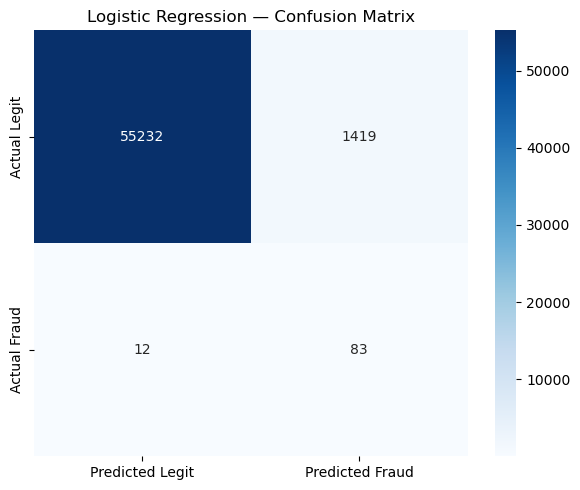

In [10]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/05_lr_confusion_matrix.png', dpi=150)
plt.show()


In [11]:
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (Fraud caught):     {tp}")
print(f"False Positives (Legit flagged):    {fp}")
print(f"True Negatives  (Legit cleared):    {tn}")
print(f"False Negatives (Fraud missed):     {fn}")
print(f"\nFraud detection rate (Recall):      {tp/(tp+fn)*100:.2f}%")
print(f"False alarm rate:                   {fp/(fp+tn)*100:.4f}%")


True Positives  (Fraud caught):     83
False Positives (Legit flagged):    1419
True Negatives  (Legit cleared):    55232
False Negatives (Fraud missed):     12

Fraud detection rate (Recall):      87.37%
False alarm rate:                   2.5048%
